In [1]:
import graphviz as gv 

In [2]:
%%file vestuario.txt
reloj:
ropa_interior: pantalones zapatos
medias: zapatos
pantalones: zapatos correa
camiseta: correa corbata
zapatos:
correa: chaqueta
corbata: chaqueta
chaqueta:

Overwriting vestuario.txt


In [3]:
with open('vestuario.txt') as f:
  labels = []
  w2i = dict()
  info = []
  for line in f:
    node, neighbours = [elem.strip() for elem in line.split(":")]
    neighbours = neighbours.split()
    w2i[node] = len(labels)
    labels.append(node)
    info.append(neighbours)

In [4]:
G = []

for neighbours in info:
  G.append([w2i[node] for node in neighbours])

In [5]:
print(w2i)
print(labels)
print(G)

{'reloj': 0, 'ropa_interior': 1, 'medias': 2, 'pantalones': 3, 'camiseta': 4, 'zapatos': 5, 'correa': 6, 'corbata': 7, 'chaqueta': 8}
['reloj', 'ropa_interior', 'medias', 'pantalones', 'camiseta', 'zapatos', 'correa', 'corbata', 'chaqueta']
[[], [3, 5], [5], [5, 6], [6, 7], [], [8], [8], []]


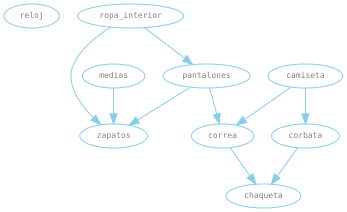

In [6]:
def show(G, labels=None, directed=False, path=[], layout='dot'):
    g = gv.Digraph() if directed else gv.Graph()
    g.edge_attr["color"] = "skyblue"
    g.node_attr["color"] = "skyblue"
    g.node_attr["width"] = "0.1"
    g.node_attr["height"] = "0.1"
    g.node_attr["fontsize"] = "8"
    g.node_attr["fontcolor"] = "gray"
    g.node_attr["fontname"] = "monospace"
    g.edge_attr["fontsize"] = "8"
    g.edge_attr["fontname"] = "monospace"
    g.attr(layout=layout)
    for i, label in enumerate(labels):
        g.node(str(i), label)
    for i, neighbours in enumerate(G):
        for j in neighbours:
            if directed or (j, i) not in path:
                g.edge(str(i), str(j))
    return g


show(G, labels, directed=True)

In [7]:
#Ordenamiento Topologico
def topological_sort(G):
    n = len(G)
    visited = [False]*n # Lista de nodos visitados
    order = [] # Lista de nodos en orden topologico
    def dfs(u):
        # Marcar como visitado
        visited[u] = True 
        for v in G[u]:
            if not visited[v]:
                dfs(v)
        order.append(u)
    for u in range(n):
        # Si no ha sido visitado, llamar a dfs
        if not visited[u]:
            dfs(u)
    return order[::-1]

In [8]:
ts = topological_sort(G)
print([labels[i] for i in ts])

['camiseta', 'corbata', 'medias', 'ropa_interior', 'pantalones', 'correa', 'chaqueta', 'zapatos', 'reloj']
